In [6]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
import os
os.environ["PYTHONUTF8"] = "1"
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(os.path.abspath('../pipeline'))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Rozpoczynam analizę zbieżności...
Symulacja dla hx = 0.2...
-> Wynik: 32.1867 C
Symulacja dla hx = 0.1...
-> Wynik: 25.7703 C
Symulacja dla hx = 0.05...
-> Wynik: 25.2587 C


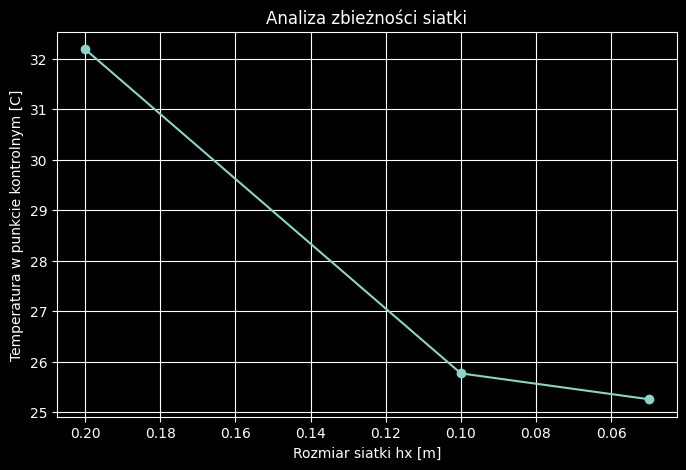

In [7]:
from grid import Grid
from solver import Solver
def run_simulation_with_hx(new_hx):
    temp_grid = Grid(config_path='data/config.json')


    temp_grid.config['config']['hx'] = new_hx
    temp_grid.config['config']['hy'] = new_hx
    temp_grid.hx = new_hx
    temp_grid.hy = new_hx
    temp_grid.nx = int(temp_grid.width_m / new_hx) + 1
    temp_grid.ny = int(temp_grid.height_m / new_hx) + 1
    temp_grid.material_grid = np.zeros((temp_grid.ny, temp_grid.nx))
    temp_grid._build_grid()

    s = Solver(temp_grid)
    s.c_set['total_time_h'] = 1.0
    res = s.solve(strategia='A')

    return res['temp'][-1]

hx_values = [0.2, 0.1, 0.05]
results = []

print("Rozpoczynam analizę zbieżności...")
for h in hx_values:
    print(f"Symulacja dla hx = {h}...")
    temp = run_simulation_with_hx(h)
    results.append(temp)
    print(f"-> Wynik: {temp:.4f} C")

plt.figure(figsize=(8,5))
plt.plot(hx_values, results, 'o-')
plt.xlabel("Rozmiar siatki hx [m]")
plt.ylabel("Temperatura w punkcie kontrolnym [C]")
plt.title("Analiza zbieżności siatki")
plt.grid(True)
plt.gca().invert_xaxis()
plt.show()